In [1]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score,confusion_matrix
import matplotlib.pyplot as plt

In [2]:
img_width,img_height=224,224
train_dir='C:\\Users\\HP\\Documents\\pets\\train'
test_dir='C:\\Users\\HP\\Documents\\pets\\test'

In [3]:
train_datagen=ImageDataGenerator(rescale=1./255,rotation_range=30,width_shift_range=0.2,height_shift_range=0.2,
                                 shear_range=0.2,zoom_range=0.2,horizontal_flip=True)

In [4]:
test_datagen=ImageDataGenerator(rescale=1./255)

In [5]:
train_generator=train_datagen.flow_from_directory(train_dir,target_size=(img_width,img_height),batch_size=32,class_mode='binary')

Found 100 images belonging to 2 classes.


In [11]:
test_generator=test_datagen.flow_from_directory(test_dir,target_size=(img_width,img_height),batch_size=32,class_mode='binary')

Found 100 images belonging to 2 classes.


In [13]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [15]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_generator,epochs=10,validation_data=test_generator)

C:\Users\HP\anaconda3\anacondainternship\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.4476 - loss: 2.1860 - val_accuracy: 0.5000 - val_loss: 0.7151
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5292 - loss: 0.7493 - val_accuracy: 0.5000 - val_loss: 0.6957
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5206 - loss: 0.6895 - val_accuracy: 0.5000 - val_loss: 0.7051
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5056 - loss: 0.6937 - val_accuracy: 0.5100 - val_loss: 0.6983
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5184 - loss: 0.6874 - val_accuracy: 0.5200 - val_loss: 0.6969
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6106 - loss: 0.6959 - val_accuracy: 0.5200 - val_loss: 0.6929
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6099 - loss: 0.6847 - val_accuracy: 0.5100 - val_loss: 0.6979
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6283 - loss: 0.6644 

In [19]:
test_loss,test_acc=model.evaluate(test_generator)
print(f'Test accuracy:{test_acc:.2f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 611ms/step - accuracy: 0.5290 - loss: 0.6958
Test accuracy:0.51


Text(0, 0.5, 'Accuracy')

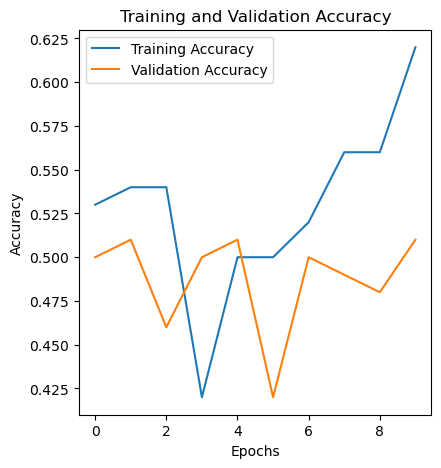

In [21]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy')
plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

Text(0, 0.5, 'Loss')

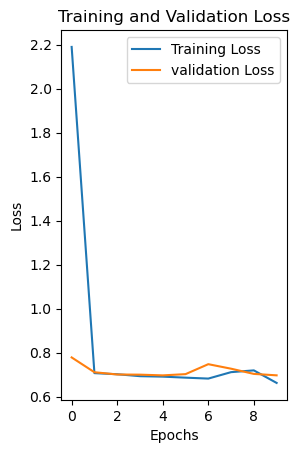

In [23]:
4
plt.plot(history.history['val_loss'],
         label='validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [47]:
def classify_image(image_path):
    img = load.img(image_path,target_size=(img_width,img_height))
    img_array=np.array(img)/255.0
    img_array=np.expand_dims(img_array,axis=0)
    predictions=model.predict(img_array)
    class_index=np.argmax(predictions)
    class_label=test_generator.class_indices[class_index]
    return class_label
 

In [49]:
image_path= 'C:\\Users\\HP\\Documents\\pets\\test\\cat\\cat_165.jpg'
class_label=classify_image('C:\\Users\\HP\\Documents\\pets\\test\\cat\\cat_165.jpg')
print(f'Class_Label:{class_label}')

NameError: name 'load' is not defined